# Lib


In [ ]:
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings("ignore")

# Data


In [ ]:
# Load Labels
df_target = pd.read_csv("../data/github_social_network/musae_git_target.csv")
df_target.columns = df_target.columns.str.strip().str.lower().str.replace(" ", "_")

# Load Edges
df_edges = pd.read_csv("../data/github_social_network/musae_git_edges.csv")
df_edges.columns = df_edges.columns.str.strip().str.lower().str.replace(" ", "_")

# Load Features
with open("../data/github_social_network/musae_git_features.json", "r") as f:
    features_json = json.load(f)

In [4]:
df_target.head()

,id,name,ml_target
0,0,Eiryyy,0
1,1,shawflying,0
2,2,JpMCarrilho,1
3,3,SuhwanCha,0
4,4,sunilangadi2,1


In [5]:
df_edges.head()

,id_1,id_2
0,0,23977
1,1,34526
2,1,2370
3,1,14683
4,1,29982


# EDA


In [8]:
num_nodes = len(df_target)
num_edges = len(df_edges)

print(f"Tổng số lập trình viên (Nodes): {num_nodes:,}")
print(f"Tổng số quan hệ Follow (Edges): {num_edges:,}")

Tổng số lập trình viên (Nodes): 37,700
Tổng số quan hệ Follow (Edges): 289,003


In [11]:
print(df_target.isnull().sum())
print()
print(df_edges.isnull().sum())

id           0
name         0
ml_target    0
dtype: int64

id_1    0
id_2    0
dtype: int64


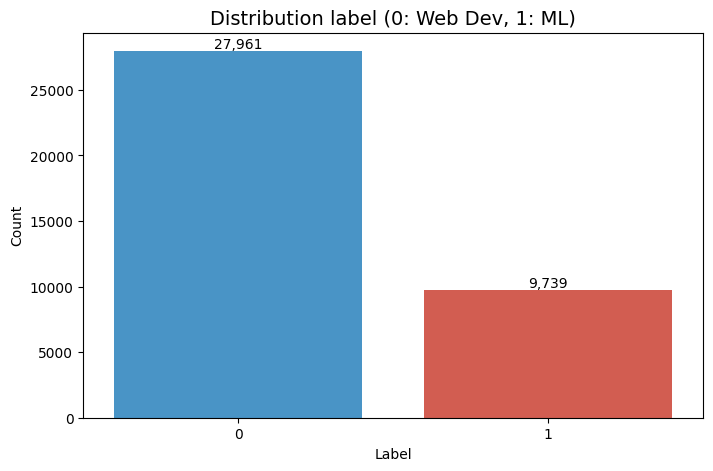

In [20]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_target, x="ml_target", palette=["#3498db", "#e74c3c"])
plt.title("Distribution label (0: Web Dev, 1: ML)", fontsize=14)
plt.ylabel("Count")
plt.xlabel("Label")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 5),
        textcoords="offset points",
    )

plt.show()

In [ ]:
ml_count = df_target["ml_target"].sum()
print("Distribution Label:")
print(
    f"\tML: {ml_count/num_nodes*100:.2f}%\n\tWeb Dev: {(num_nodes-ml_count)/num_nodes*100:.2f}%"
)

Distribution Label:
	ML: 25.83%
	Web Dev: 74.17%


# Feature processing


In [ ]:
feature_list = []
for i in range(num_nodes):
    node_str = str(i)
    if node_str in features_json:
        feats = features_json[node_str]
        feat_str = " ".join([f"feat_{f}" for f in feats])
        feature_list.append(feat_str)
    else:
        feature_list.append("")

df_nodes = df_target.copy()
df_nodes["features"] = feature_list
df_nodes["num_features"] = df_nodes["features"].apply(
    lambda x: len(x.split()) if x != "" else 0
)

In [27]:
df_nodes.head()

,id,name,ml_target,features,num_features
0,0,Eiryyy,0,feat_1574 feat_3773 feat_3571 feat_2672 feat_2...,19
1,1,shawflying,0,feat_1193 feat_376 feat_73 feat_290 feat_3129 ...,17
2,2,JpMCarrilho,1,feat_1574 feat_3773 feat_925 feat_1728 feat_28...,19
3,3,SuhwanCha,0,feat_3964 feat_3773 feat_4003 feat_928 feat_18...,15
4,4,sunilangadi2,1,feat_1929 feat_3773 feat_1793 feat_3511 feat_1...,19


# Save


In [ ]:
nodes_output_path = "../data/processed/nodes.csv"
edges_output_path = "../data/processed/edges.csv"

In [29]:
df_nodes.to_csv(nodes_output_path, index=False)
df_edges.to_csv(edges_output_path, index=False)

In [31]:
print(f"File Nodes: {nodes_output_path} - (Shape: {df_nodes.shape})")
print(f"File Edges: {edges_output_path} - (Shape: {df_edges.shape})")

File Nodes: ../data/processed/nodes_processed.csv - (Shape: (37700, 5))
File Edges: ../data/processed/edges_processed.csv - (Shape: (289003, 2))
